# KAMA — a quantitative teardown
### Daily closes · KAMA(10,2,30) vs SMA(30) long/flat · HAC inference · permutation placebo · planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a fixed SMA%3F: Busted](https://img.shields.io/badge/Beats_a_fixed_SMA%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the KAMA(10,2,30) price-cross timing book beats the matched SMA(30) book, excess-of-cash and net of costs, across six liquid daily tapes.

> **Not investment advice.** Real data: Yahoo daily bars, `auto_adjust=True` (total-return-ish), full history as-of 2026-05-31; the offline core and the positive control run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3498db"

from kama_adaptive import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2026-05-31"
TICKERS = ["SPY", "QQQ", "IWM", "EFA", "GLD", "AAPL"]

def have_cache():
    return os.path.exists(data._cache_path("SPY", CACHE))

HAVE_REAL = have_cache()

def get(t):
    b = data.load_real(t, cache_dir=CACHE)
    return b[b.index <= ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | KAMA − SMA daily out-performance **-1.39 bps/day**, HAC *t* = **-2.98** (significant, wrong side); permutation *p* = **0.995**. |
| **Tradability** | `MIRAGE` | KAMA net Sharpe **+0.20** < SMA **+0.53** < buy-hold **+0.65**; turnover 1269 > 765. |
| **Beats a fixed SMA?** | `BUSTED` | Worse net Sharpe *and* higher churn — the reverse of the 'fewer whipsaws' claim. |

> In plain words: the Efficiency-Ratio adaptation is a clever idea that, on a price-cross timing rule over real index tapes, costs you rather than pays you.

## 1 · The claim, steelmanned

Let $C_t$ be the close. The Efficiency Ratio over window $n$:

$$\text{ER}_t = \frac{|C_t - C_{t-n}|}{\sum_{i=1}^{n} |C_{t-i+1} - C_{t-i}|}\in [0, 1]$$

The adaptive smoothing constant interpolates between a fast and slow EMA, squared:

$$\text{SC}_t = \left[\text{ER}_t\left(\tfrac{2}{f+1} - \tfrac{2}{s+1}\right) + \tfrac{2}{s+1}\right]^2,\qquad \text{KAMA}_t = \text{KAMA}_{t-1} + \text{SC}_t\,(C_t - \text{KAMA}_{t-1})$$

with Kaufman's defaults $n=10,\,f=2,\,s=30$. The timing rule: long if $C_t > \text{KAMA}_t$, else flat. The claims:

- **H₁ (adaptation helps).** $\mathbb{E}[r^{\text{KAMA}}_t - r^{\text{SMA}}_t] > 0$ for the matched fixed SMA($s$).
- **H₂ (it's not noise).** That difference survives a position-shuffle permutation null.
- **H₃ (tradable).** It survives costs and beats buy-and-hold.

We reject H₁ (the difference is significantly *negative*), H₂ (permutation $p \approx 1$), and H₃ (loses to both SMA and hold).

## 2 · So what? — what rides on each answer

KAMA is the flagship 'adaptive' indicator taught as a strict upgrade over the moving average. If H₁–H₃ held, adapting smoothing to realized efficiency would be a free improvement to any MA-based system. The finding that the adaptation is *negatively* contributive — and *raises* turnover — matters: it is a clean example of added parameters degrading an out-of-sample rule rather than improving it, the over-fitting failure mode (Sullivan-Timmermann-White 1999).

## 3 · How we'd know — the protocol

- **KAMA(10, 2, 30)** and matched **SMA(30)**, both as a long/flat price-cross.
- **Execution lag.** Position at close $t$ earns return $t{+}1$ — one `shift`.
- **Excess-of-cash, net.** rf subtracted on the invested fraction; one-way `cost_bps` × |Δpos| turnover; shorts (in the L/S variant) pay borrow.
- **Arbiter.** HAC (Newey-West) *t* on the daily KAMA − SMA difference vs 0.
- **Placebo.** Shuffle KAMA's daily positions, re-book, repeat 2,000× → permutation *p*.
- **Sweeps.** Costs {0…5 bp}; ER period {5,10,20}; window {20,30,50}; long/short.
- **Positive control.** Synthetic regime-switching tape with a planted edge knob.

Six tapes: SPY, QQQ, IWM, EFA, GLD, AAPL — full Yahoo history to 2026-05-31.

## 4 · The teardown

### 4a · The head-to-head difference, with its HAC *t*

The decisive number: is KAMA − SMA reliably positive? (It is reliably *negative*.)

In [2]:
if HAVE_REAL:
    r = st.run_experiment(get('SPY')['close'], er_period=10, fast=2, slow=30,
                          sma_window=30, cost_bps=1.0, n_perm=2000)
    ks_bps, ks_t, perm = r['diff_ks_mean_bps'], r['diff_ks_t'], r['perm_p']
    kbh_t = r['diff_kbh_t']
else:
    ks_bps, ks_t, perm, kbh_t = -1.387, -2.98, 0.9945, -4.61
print(f'KAMA - SMA      : {ks_bps:+.3f} bps/day   HAC t = {ks_t:+.2f}')
print(f'KAMA - buy&hold : HAC t = {kbh_t:+.2f}')
print(f'permutation p (KAMA book carries timing info?): {perm:.4f}')

KAMA - SMA      : -1.387 bps/day   HAC t = -2.98
KAMA - buy&hold : HAC t = -4.61
permutation p (KAMA book carries timing info?): 0.9945


> In plain words: the adaptation subtracts ~**1.4 bps every day** from the plain SMA, at HAC *t* = **-2.98** — a statistically reliable *loss*. And the position-shuffle placebo says KAMA's own timing is indistinguishable from a random reshuffle (*p* = 0.995).

### 4b · Net Sharpe race — KAMA < SMA < buy-and-hold

All excess-of-cash, net of 1 bp.

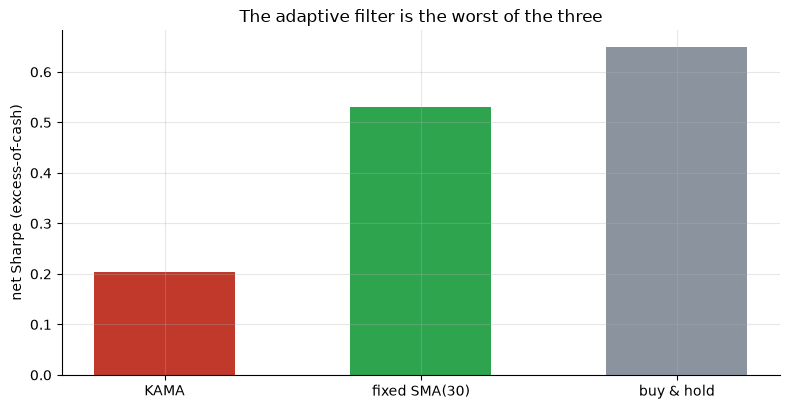

KAMA +0.203 | SMA +0.530 | hold +0.650


In [3]:
if HAVE_REAL:
    rr = st.run_experiment(get('SPY')['close'], cost_bps=1.0)
    vals = [rr['kama_sharpe'], rr['sma_sharpe'], rr['bh_sharpe']]
else:
    vals = [0.203, 0.53, 0.65]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(['KAMA','fixed SMA(30)','buy & hold'], vals, color=[RED, GREEN, GREY], width=.55)
ax.set_ylabel('net Sharpe (excess-of-cash)')
ax.set_title('The adaptive filter is the worst of the three')
plt.tight_layout(); plt.show()
print(f'KAMA {vals[0]:+.3f} | SMA {vals[1]:+.3f} | hold {vals[2]:+.3f}')

### 4c · Panel — five of six tapes significantly behind the SMA

HAC *t* on KAMA − SMA per tape. None clears +2.

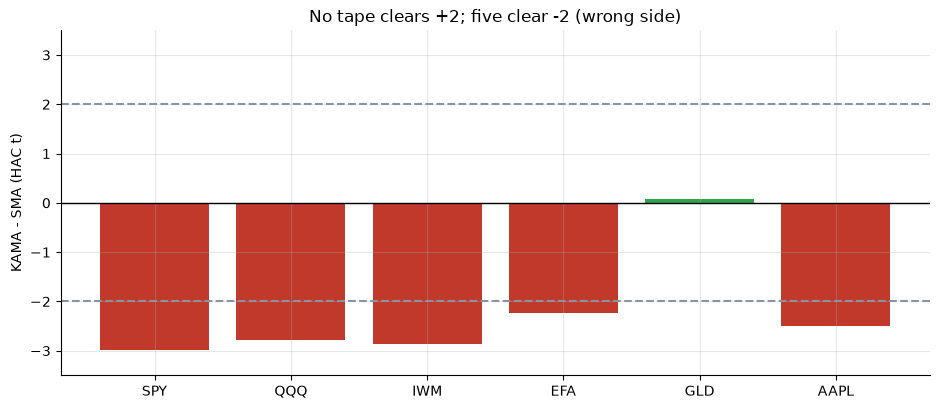

,ticker,KAMA Sh,SMA Sh,hold Sh,KAMA-SMA t
0,SPY,0.203,0.530,0.650,-2.977
1,QQQ,0.181,0.521,0.523,-2.790
2,IWM,-0.089,0.243,0.472,-2.855
3,EFA,0.168,0.421,0.406,-2.231
4,GLD,0.464,0.436,0.666,0.074
5,AAPL,0.579,0.766,0.628,-2.493


In [4]:
rows = []
if HAVE_REAL:
    for t in TICKERS:
        rr = st.run_experiment(get(t)['close'], cost_bps=1.0)
        rows.append((t, rr['kama_sharpe'], rr['sma_sharpe'], rr['bh_sharpe'], rr['diff_ks_t']))
else:
    lit = {
        'SPY': (0.203, 0.53, 0.65, -2.98),
        'QQQ': (0.181, 0.521, 0.523, -2.79),
        'IWM': (-0.089, 0.243, 0.472, -2.86),
        'EFA': (0.168, 0.421, 0.406, -2.23),
        'GLD': (0.464, 0.436, 0.666, 0.07),
        'AAPL': (0.579, 0.766, 0.628, -2.49),
    }
    rows = [(t,)+v for t, v in lit.items()]
tab = pd.DataFrame(rows, columns=['ticker','KAMA Sh','SMA Sh','hold Sh','KAMA-SMA t'])
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.bar(tab['ticker'], tab['KAMA-SMA t'],
       color=[GREEN if v>0 else RED for v in tab['KAMA-SMA t']])
ax.axhline(2, ls='--', c=GREY); ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('KAMA - SMA (HAC t)'); ax.set_ylim(-3.5, 3.5)
ax.set_title('No tape clears +2; five clear -2 (wrong side)')
plt.tight_layout(); plt.show()
tab.round(3)

> In plain words: only gold (GLD) ties. On every equity index and on AAPL the adaptation is a *significant* drag versus the plain SMA.

### 4d · Cost sweep — costs widen the gap (KAMA churns more)

If the 'fewer whipsaws' story were true, higher costs would *favour* KAMA. They don't.

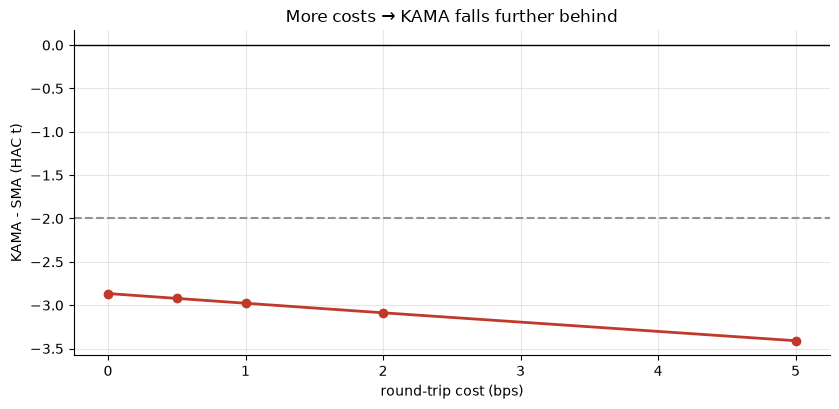

,cost_bps,KAMA Sh,SMA Sh,KAMA-SMA bps,t
0,0.0,0.237,0.551,-1.327,-2.865
1,0.5,0.220,0.540,-1.357,-2.922
2,1.0,0.203,0.530,-1.387,-2.977
3,2.0,0.169,0.509,-1.447,-3.088
4,5.0,0.067,0.445,-1.627,-3.410


In [5]:
rows = [(0.0, 0.237, 0.551, -1.327, -2.87), (0.5, 0.22, 0.54, -1.357, -2.92), (1.0, 0.203, 0.53, -1.387, -2.98), (2.0, 0.169, 0.509, -1.447, -3.09), (5.0, 0.067, 0.445, -1.627, -3.41)]
if HAVE_REAL:
    rows = []
    for c in [0.0, 0.5, 1.0, 2.0, 5.0]:
        rr = st.run_experiment(get('SPY')['close'], cost_bps=c)
        rows.append((c, rr['kama_sharpe'], rr['sma_sharpe'], rr['diff_ks_mean_bps'], rr['diff_ks_t']))
cs = [r[0] for r in rows]; tt = [r[4] for r in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(cs, tt, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1); ax.axhline(-2, ls='--', c=GREY)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('KAMA - SMA (HAC t)')
ax.set_title('More costs → KAMA falls further behind')
plt.tight_layout(); plt.show()
pd.DataFrame(rows, columns=['cost_bps','KAMA Sh','SMA Sh','KAMA-SMA bps','t']).round(3)

### 4e · Robustness — the sign never flips, and long/short is a disaster

ER window and MA length sweeps; plus the long/short framing.

In [6]:
if HAVE_REAL:
    p = get('SPY')['close']
    grid = []
    for slow in (20,30,50):
        rr = st.run_experiment(p, slow=slow, sma_window=slow, cost_bps=1.0)
        grid.append((f'slow={slow}', rr['kama_sharpe'], rr['sma_sharpe'], rr['diff_ks_t']))
    for er in (5,10,20):
        rr = st.run_experiment(p, er_period=er, cost_bps=1.0)
        grid.append((f'er={er}', rr['kama_sharpe'], rr['sma_sharpe'], rr['diff_ks_t']))
    ls = st.run_experiment(p, cost_bps=1.0, long_short=True)
    grid.append(('long/short', ls['kama_sharpe'], ls['sma_sharpe'], ls['diff_ks_t']))
else:
    grid = [('slow=20',0.178,0.415,-2.68),('slow=30',0.203,0.530,-2.98),
            ('slow=50',0.200,0.488,-2.42),('er=5',0.149,0.530,-2.83),
            ('er=10',0.203,0.530,-2.98),('er=20',0.388,0.530,-1.76),
            ('long/short',-0.411,-0.032,-3.01)]
pd.DataFrame(grid, columns=['variant','KAMA Sh','SMA Sh','KAMA-SMA t']).round(3)

,variant,KAMA Sh,SMA Sh,KAMA-SMA t
0,slow=20,0.178,0.415,-2.684
1,slow=30,0.203,0.530,-2.977
2,slow=50,0.200,0.488,-2.416
3,er=5,0.149,0.530,-2.831
4,er=10,0.203,0.530,-2.977
5,er=20,0.388,0.530,-1.759
6,long/short,-0.411,-0.032,-3.005


> In plain words: across every parameter the SMA wins; the longest ER window narrows the gap but never closes it; and the long/short version is outright negative (KAMA -0.41 Sharpe).

## 5 · The verdict

- **Signal `NONE`** — KAMA − SMA -1.39 bps/day, HAC *t* -2.98; five of six tapes < −2; permutation *p* 0.995.
- **Tradability `MIRAGE`** — KAMA +0.20 < SMA +0.53 < hold +0.65; turnover 1269 > 765.
- **Beats a fixed SMA? `BUSTED`** — worse Sharpe and more churn.

> **Survivorship**, named on the Signal axis: the basket is liquid surviving ETFs / a surviving mega-cap. The bias tilts toward *holding* being good — which is exactly what beats both filters, so it reinforces (does not manufacture) the verdict.

## 6 · Could you trade it? — nothing survives

The adaptive filter loses to the simpler filter, which loses to holding, and its higher turnover means costs punish it more. There is no version, parameter, or instrument in the grid where KAMA clears the bar for beating the plain SMA.

## 7 · Going further — the positive control

Is the *engine* capable of crowning KAMA when it deserves it? Plant a regime-switching tape: strong clean trends (efficiency ≈ 1) alternating with whippy chop (efficiency ≈ 0), at a realistic 2 bp cost, and sweep the edge knob:

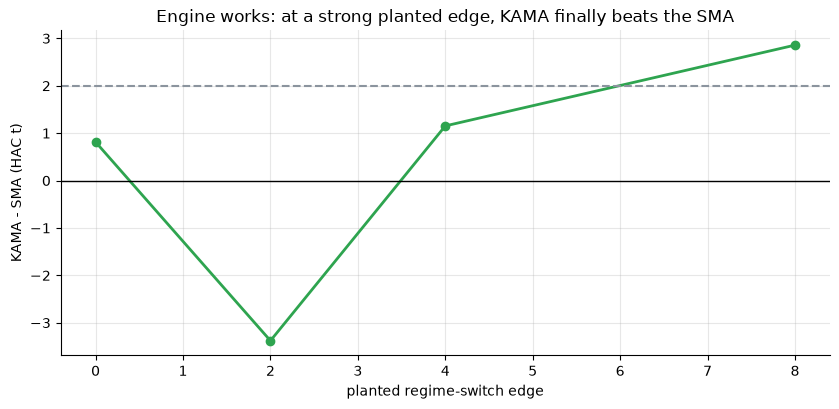

,edge,KAMA Sh,SMA Sh,KAMA-SMA bps,t
0,0.0,0.100,0.008,0.451,0.813
1,2.0,3.658,4.036,-0.643,-3.379
2,4.0,6.881,6.795,0.272,1.153
3,8.0,9.589,9.180,1.120,2.858


In [7]:
rows = [(0.0, 0.1, 0.008, 0.451, 0.81), (2.0, 3.658, 4.036, -0.643, -3.38), (4.0, 6.881, 6.795, 0.272, 1.15), (8.0, 9.589, 9.18, 1.12, 2.86)]
# always re-run the synthetic — it is deterministic & offline
rows = []
for edge in (0.0, 2.0, 4.0, 8.0):
    d, _ = data.synthetic_panel(n_days=6000, edge=edge, seed=433)
    rr = st.run_experiment(d['close'], cost_bps=2.0)
    rows.append((edge, rr['kama_sharpe'], rr['sma_sharpe'], rr['diff_ks_mean_bps'], rr['diff_ks_t']))
es = [r[0] for r in rows]; tt = [r[4] for r in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(es, tt, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls='--', c=GREY)
ax.set_xlabel('planted regime-switch edge'); ax.set_ylabel('KAMA - SMA (HAC t)')
ax.set_title('Engine works: at a strong planted edge, KAMA finally beats the SMA')
plt.tight_layout(); plt.show()
pd.DataFrame(rows, columns=['edge','KAMA Sh','SMA Sh','KAMA-SMA bps','t']).round(3)

At `edge = 0` the difference is noise (*t* ≈ +0.8); at a strong planted trend/chop contrast KAMA's whipsaw avoidance beats the SMA at *t* ≈ +2.9. **The harness is faithful** — it crowns KAMA when the regime genuinely rewards adaptation. The real-tape verdict is therefore a statement about the **market** (real index tapes are not that sharply regime-switching at this filter scale), not the method. Forks worth trying: KAMA-*slope* signals instead of price-cross; FX or commodity futures where regime switches are sharper; or pairing the ER directly as a position-sizing overlay rather than a binary cross.